# Démonstration : Introduction aux Réseaux de Neurones
## Cas Pratique : Prédiction de l'état écologique des cours d'eau

Ce carnet (notebook) a pour objectif de démystifier le fonctionnement d'un réseau de neurones artificiels (Perceptron Multicouche) auprès des équipes de la DSI du Ministère de la Transition écologique.

Nous allons simuler l'analyse en temps réel de capteurs connectés (IoT) placés dans les cours d'eau pour détecter d'éventuelles pollutions.

### 1. Importation des bibliothèques nécessaires
Nous utilisons `Scikit-Learn` pour la préparation des données et `TensorFlow/Keras` pour la construction du réseau de neurones.

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

### 2. Génération du jeu de données (Dataset)
Dans un contexte réel, ces données proviendraient de l'API Hub'Eau ou d'un Data Lakehouse du ministère. 
Pour cette démonstration, nous générons des données synthétiques basées sur 4 indicateurs : le **pH**, le taux d'**oxygène dissous**, la **turbidité** (particules en suspension) et la **température**.

In [3]:
# Fixer la graine aléatoire pour la reproductibilité
np.random.seed(42)
n_samples = 1000

# Nos 4 entrées (X) : pH, Oxygène (mg/L), Turbidité (NTU), Température (°C)
X = np.random.rand(n_samples, 4) * [14, 15, 100, 30] 

# Création d'une règle "métier" que le modèle doit découvrir par lui-même :
# Si le taux d'oxygène moins un dixième de la turbidité est positif -> Bon état (1)
# Sinon -> Anomalie / Pollution (0)
y = ((X[:, 1] - X[:, 2]/10) > 0).astype(int)

# Affichage d'un échantillon
print("Exemple de données brutes (X) :", X[0])
print("État correspondant (y) :", y[0])

Exemple de données brutes (X) : [ 5.24356166 14.2607146  73.19939418 17.95975453]
État correspondant (y) : 1


### 3. Préparation et normalisation
**Étape cruciale !** Les algorithmes sont sensibles aux échelles de valeurs. La turbidité (qui va jusqu'à 100) écraserait mathématiquement le pH (qui plafonne à 14). Le `StandardScaler` ramène toutes les variables sur une échelle comparable (autour de 0).

In [4]:
# Séparation : 80% pour l'entraînement, 20% pour le test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Exemple de données normalisées :", X_train_scaled[0])

Exemple de données normalisées : [ 1.02861829 -1.04073902  1.37429781  0.11316246]


### 4. Architecture du Réseau de Neurones
Nous construisons un réseau séquentiel simple :
* **Couche d'entrée** implicite de 4 neurones (nos 4 variables).
* **Couches cachées** : Elles utilisent la fonction d'activation `ReLU` pour capter les effets non linéaires (les interactions complexes entre la température et le pH, par exemple).
* **Couche de sortie** : Un seul neurone avec la fonction `Sigmoïde` pour renvoyer une probabilité (entre 0 et 1).

In [5]:
model = Sequential([
    Dense(16, activation='relu', input_shape=(4,), name="Couche_Cachee_1"),
    Dense(8, activation='relu', name="Couche_Cachee_2"),
    Dense(1, activation='sigmoid', name="Sortie_Probabilite")
])

# Compilation du modèle : on définit la règle du jeu (Loss) et l'optimiseur
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Résumé de l'architecture
model.summary()

/Users/pierrejaumier/miniconda3/envs/tf/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Couche_Cachee_1 (Dense)         │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Couche_Cachee_2 (Dense)         │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Sortie_Probabilite (Dense)      │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

### 5. Entraînement du Modèle (Training)
Le réseau va lire les données par lots (batch) et ajuster ses "poids" mathématiques à chaque époque (epoch) pour réduire ses erreurs (Backpropagation).

In [6]:
print("--- Début de l'apprentissage ---")
history = model.fit(
    X_train_scaled, 
    y_train, 
    epochs=30, 
    batch_size=32, 
    validation_split=0.2,
    verbose=1 # Affiche la progression
)

--- Début de l'apprentissage ---
Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4828 - loss: 0.7209 - val_accuracy: 0.5938 - val_loss: 0.6547
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5880 - loss: 0.6510 - val_accuracy: 0.6750 - val_loss: 0.6037
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7081 - loss: 0.5926 - val_accuracy: 0.7688 - val_loss: 0.5576
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8570 - loss: 0.5379 - val_accuracy: 0.8500 - val_loss: 0.5133
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8776 - loss: 0.4884 - val_accuracy: 0.8625 - val_loss: 0.4718
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9094 - loss: 0.4450 - val_accuracy: 0.8875 - val_loss: 0.4290
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9222 - loss: 0.3852 - val_accuracy: 0.9250 - val_loss: 0.3859
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9475 - loss: 0.3541 -

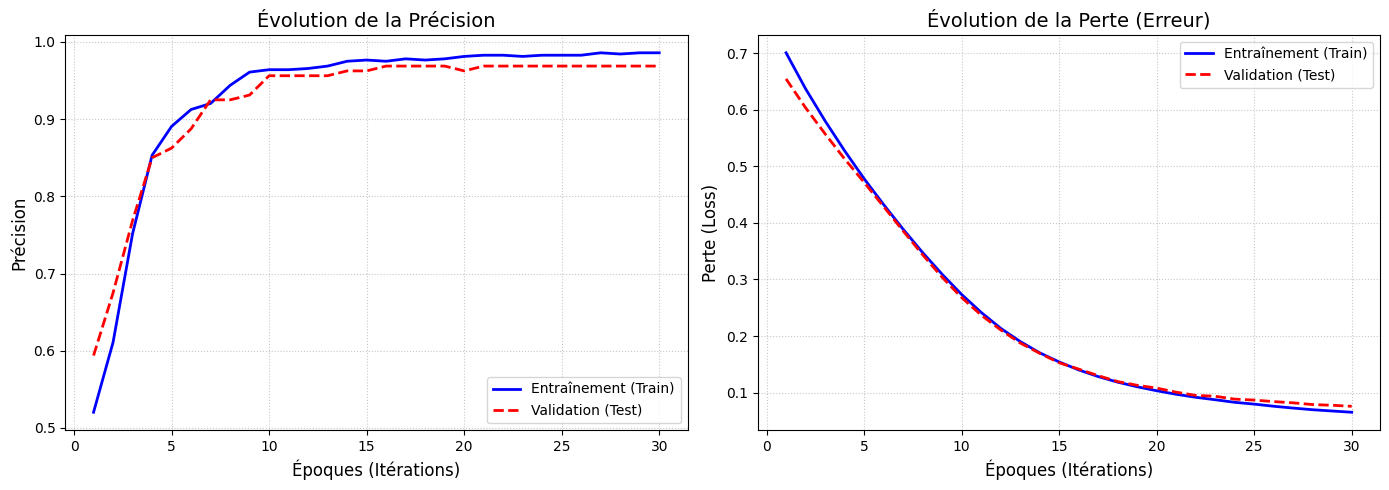

In [8]:
import matplotlib.pyplot as plt

# L'objet 'history' contient l'historique de toutes les métriques à chaque époque
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# Création d'une figure avec deux graphiques côte à côte
plt.figure(figsize=(14, 5))

# 1er Graphique : Évolution de la Précision (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-', label='Entraînement (Train)', linewidth=2)
plt.plot(epochs, val_acc, 'r--', label='Validation (Test)', linewidth=2)
plt.title('Évolution de la Précision', fontsize=14)
plt.xlabel('Époques (Itérations)', fontsize=12)
plt.ylabel('Précision', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)

# 2ème Graphique : Évolution de la Perte (Loss / Erreur)
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b-', label='Entraînement (Train)', linewidth=2)
plt.plot(epochs, val_loss, 'r--', label='Validation (Test)', linewidth=2)
plt.title('Évolution de la Perte (Erreur)', fontsize=14)
plt.xlabel('Époques (Itérations)', fontsize=12)
plt.ylabel('Perte (Loss)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.7)

# Affichage propre
plt.tight_layout()
plt.show()

### 6. Évaluation des performances
Vérifions si notre modèle est capable de généraliser ses connaissances sur des données qu'il n'a encore jamais vues (le jeu de test).

In [9]:
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nPrécision sur les données de test : {accuracy * 100:.2f}%")


Précision sur les données de test : 99.00%


### 7. Mise en production (Inférence)
Simulons la réception de nouvelles données provenant d'une balise IoT sur le terrain. 
* *Exemple d'alerte* : pH un peu acide (6.8), très peu d'oxygène (2.1 mg/L), eau très trouble (85 NTU).

In [10]:
# Relevé terrain : pH=6.8, Oxygène=2.1, Turbidité=85.0, Température=22.0
nouveau_releve = np.array([[6.8, 2.1, 85.0, 22.0]])

# ATTENTION : Il faut toujours appliquer la même normalisation aux nouvelles données !
releve_normalise = scaler.transform(nouveau_releve) 

# Prédiction
prediction = model.predict(releve_normalise)
probabilite_bon_etat = prediction[0][0] * 100

print("\n--- Analyse en temps réel ---")
print(f"Probabilité de conformité de l'eau : {probabilite_bon_etat:.2f}%")

# Logique métier déclenchée par l'IA
if probabilite_bon_etat < 50:
    print("-> ALERTE : Risque de pollution détecté ! Déclenchement d'un webhook vers le système de la DSI.")
else:
    print("-> STATUT : Normal. Pas d'action requise.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step

--- Analyse en temps réel ---
Probabilité de conformité de l'eau : 0.30%
-> ALERTE : Risque de pollution détecté ! Déclenchement d'un webhook vers le système de la DSI.
